# K-Nearest Neighbours (KNN) Assignment

## Dataset: Zoo.csv

**Objective:** Implement and evaluate the K-Nearest Neighbours algorithm for animal type classification.

This notebook covers:
1. Data loading and basic understanding  
2. Exploratory Data Analysis (EDA) using visualizations  
3. Missing value and outlier handling  
4. Train-test split  
5. KNN model implementation  
6. Choosing K and distance metric  
7. Model evaluation using accuracy, precision, recall, and F1-score  
8. Decision boundary visualization  
9. Interview questions with answers  


In [1]:
# If required, run this cell once to install libraries
# !pip install pandas numpy matplotlib seaborn scikit-learn

## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

## 2. Load the Dataset

In [3]:
# Load the dataset
df = pd.read_csv("Zoo.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

df.head()

Dataset loaded successfully!
Shape of dataset: (101, 18)


,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


## 3. Basic Dataset Information

In [4]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  type         101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


In [5]:
# Display column names
print("Columns in dataset:")
print(df.columns.tolist())

Columns in dataset:
['animal name', 'hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs', 'tail', 'domestic', 'catsize', 'type']


In [6]:
# Statistical summary
df.describe()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.425743,0.198020,0.584158,0.405941,0.237624,0.356436,0.554455,0.603960,0.821782,0.792079,0.079208,0.168317,2.841584,0.742574,0.128713,0.435644,2.831683
std,0.496921,0.400495,0.495325,0.493522,0.427750,0.481335,0.499505,0.491512,0.384605,0.407844,0.271410,0.376013,2.033385,0.439397,0.336552,0.498314,2.102709
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,7.000000


## 4. Data Cleaning and Preprocessing

In this dataset:
- `animal name` is only an identifier and is not useful for prediction.
- `type` is the target column.
- Other columns are features used to classify animal type.


In [7]:
# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
animal name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
type           0
dtype: int64


In [8]:
# Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [9]:
# Drop duplicate rows if present
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (101, 18)


In [10]:
# Target column distribution
print("Animal type distribution:")
print(df["type"].value_counts().sort_index())

Animal type distribution:
type
1    41
2    20
3     5
4    13
5     4
6     8
7    10
Name: count, dtype: int64


## 5. Exploratory Data Analysis (EDA)

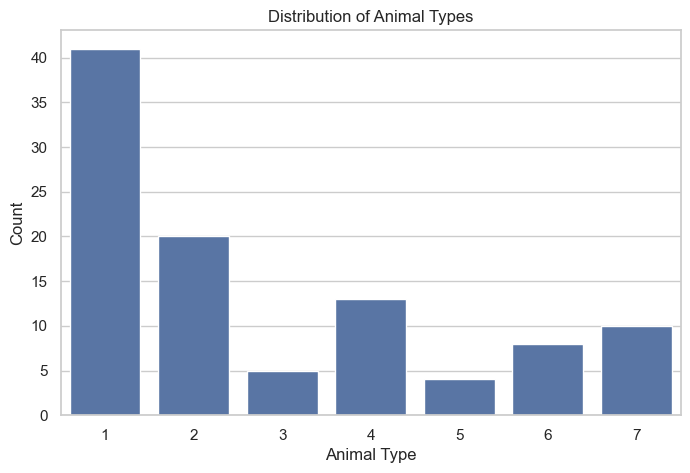

In [11]:
# Countplot of target variable
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="type")
plt.title("Distribution of Animal Types")
plt.xlabel("Animal Type")
plt.ylabel("Count")
plt.show()

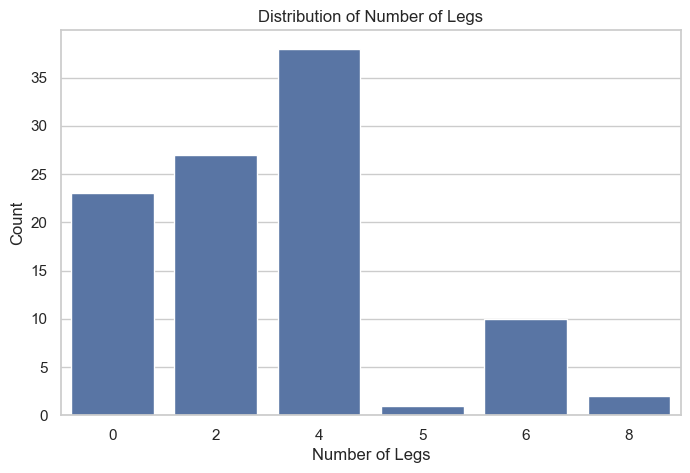

In [12]:
# Bar plot for legs count
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="legs")
plt.title("Distribution of Number of Legs")
plt.xlabel("Number of Legs")
plt.ylabel("Count")
plt.show()

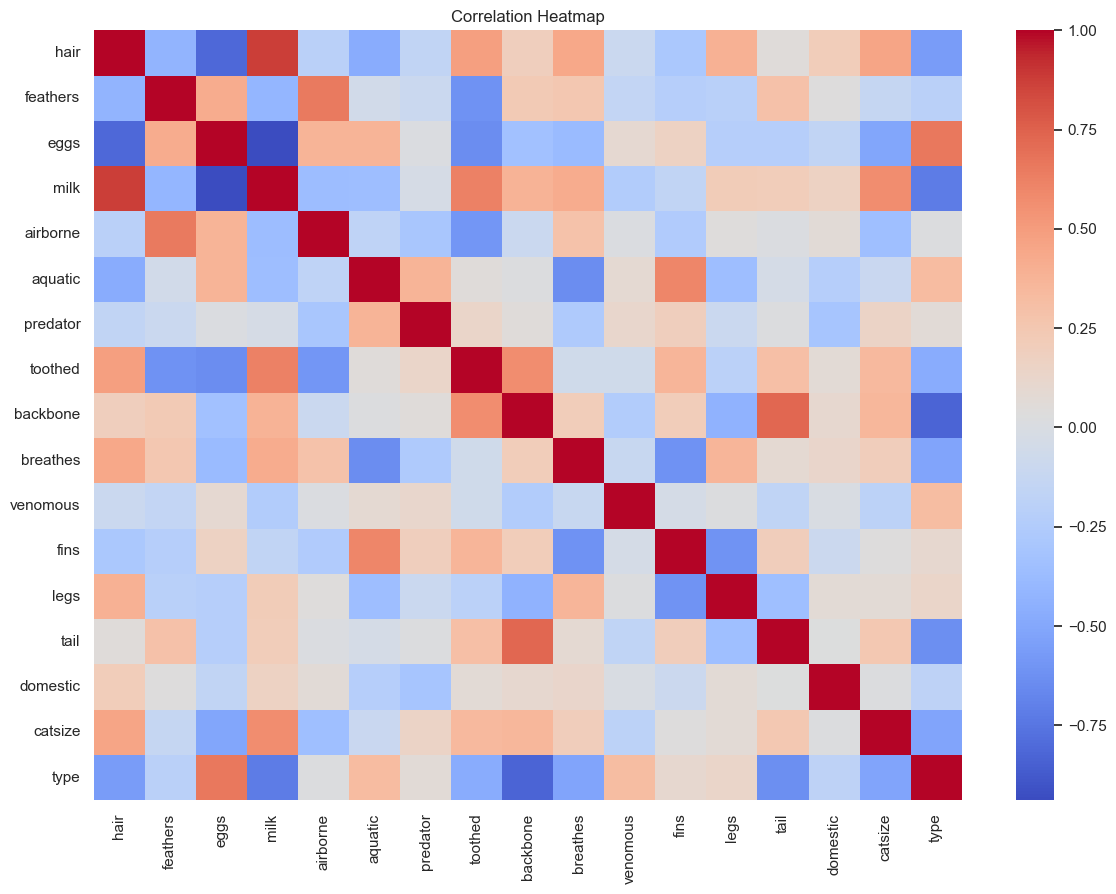

In [13]:
# Heatmap of correlations
plt.figure(figsize=(14, 10))
numeric_df = df.drop(columns=["animal name"], errors="ignore")
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

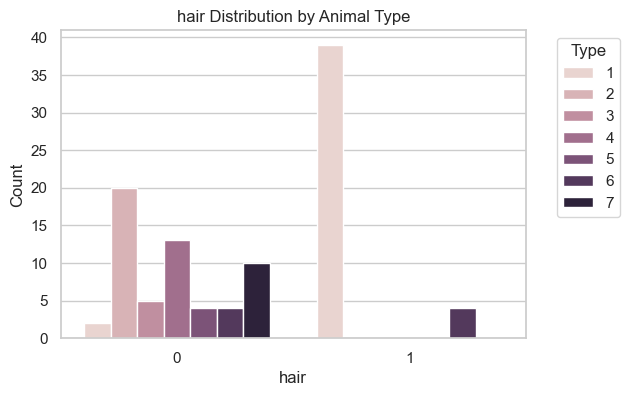

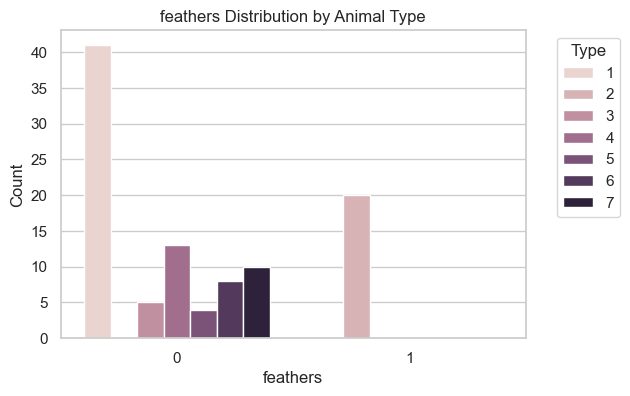

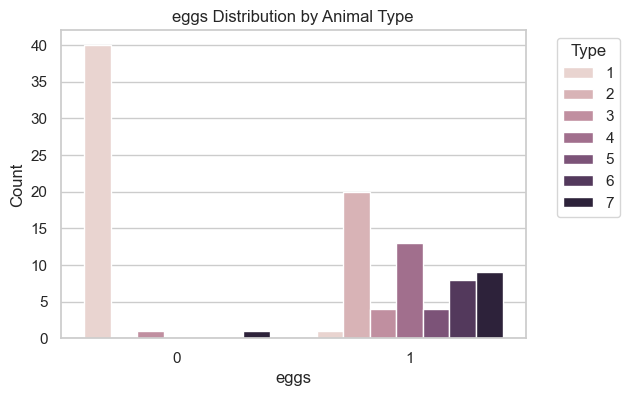

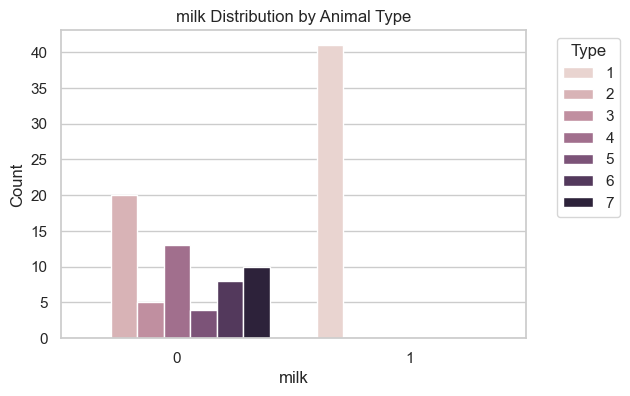

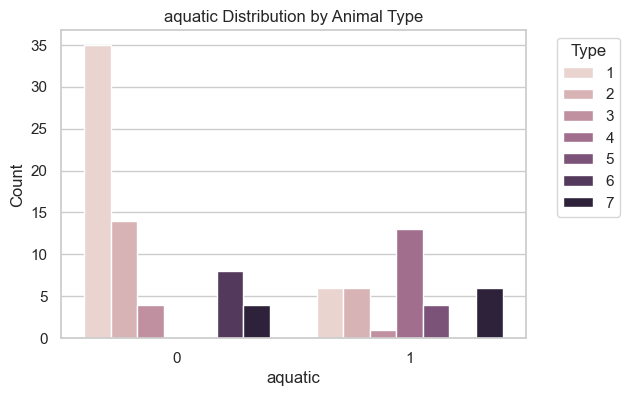

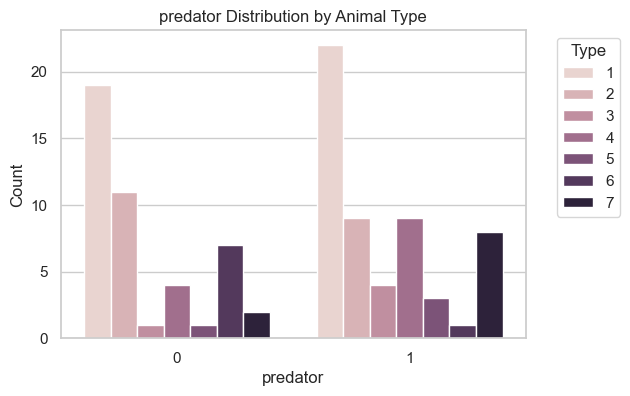

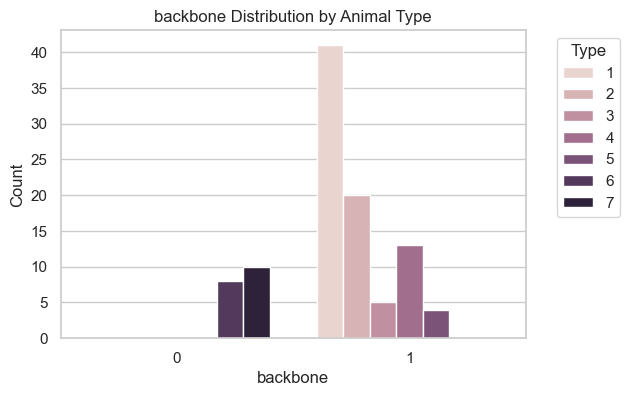

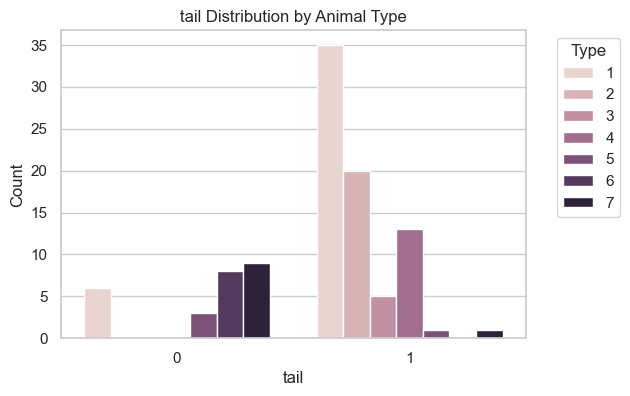

In [14]:
# Feature distribution for selected binary features
selected_features = ["hair", "feathers", "eggs", "milk", "aquatic", "predator", "backbone", "tail"]

for col in selected_features:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, hue="type")
    plt.title(f"{col} Distribution by Animal Type")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Type", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.show()

## 6. Outlier Detection

Most columns are binary values 0/1. The `legs` column can have values like 0, 2, 4, 5, 6, or 8.  
These are valid biological values, so we should not remove them as outliers.


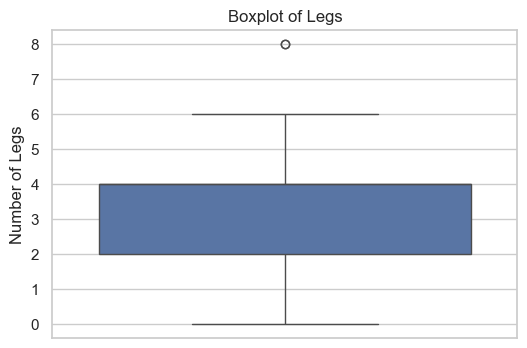

In [15]:
# Boxplot for legs
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, y="legs")
plt.title("Boxplot of Legs")
plt.ylabel("Number of Legs")
plt.show()

## 7. Feature and Target Selection

In [16]:
# Separate features and target

X = df.drop(columns=["animal name", "type"])
y = df["type"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Feature shape: (101, 16)
Target shape: (101,)


,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1
2,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0
3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1


## 8. Feature Scaling

KNN is a distance-based algorithm, so scaling is important.  
Here, `legs` has values larger than binary columns, so scaling helps avoid giving extra weight to `legs`.


In [17]:
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
0,1.161395,-0.496904,-1.185227,1.209717,-0.558291,-0.744208,0.896421,0.809776,0.46569,0.512348,-0.293294,-0.449868,0.572540,-1.698416,-0.384353,1.138180
1,1.161395,-0.496904,-1.185227,1.209717,-0.558291,-0.744208,-1.115547,0.809776,0.46569,0.512348,-0.293294,-0.449868,0.572540,0.588784,-0.384353,1.138180
2,-0.861034,-0.496904,0.843721,-0.826640,-0.558291,1.343710,0.896421,0.809776,0.46569,-1.951800,-0.293294,2.222876,-1.404435,0.588784,-0.384353,-0.878595
3,1.161395,-0.496904,-1.185227,1.209717,-0.558291,-0.744208,0.896421,0.809776,0.46569,0.512348,-0.293294,-0.449868,0.572540,-1.698416,-0.384353,1.138180
4,1.161395,-0.496904,-1.185227,1.209717,-0.558291,-0.744208,0.896421,0.809776,0.46569,0.512348,-0.293294,-0.449868,0.572540,0.588784,-0.384353,1.138180


## 9. Train-Test Split

In [18]:
# Split dataset into training and testing sets
# Stratify keeps the class distribution similar in train and test data

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (80, 16)
Testing data shape: (21, 16)
Training target shape: (80,)
Testing target shape: (21,)


## 10. Choosing the Best Value of K

We test multiple K values and select the one that gives good testing accuracy.  
Usually, odd values of K are preferred to reduce ties.


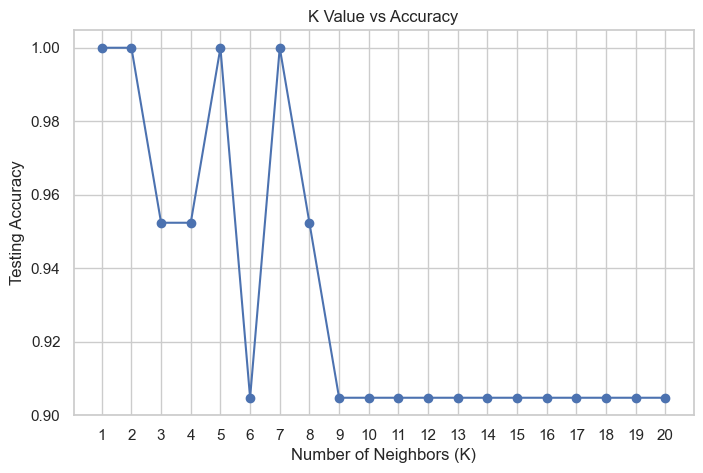

Best K value: 1
Best accuracy: 1.0


In [19]:
k_values = range(1, 21)
accuracy_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric="minkowski", p=2)  # Euclidean distance
    knn.fit(X_train, y_train)
    y_pred_k = knn.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred_k))

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracy_scores, marker="o")
plt.title("K Value vs Accuracy")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Testing Accuracy")
plt.xticks(k_values)
plt.show()

best_k = k_values[np.argmax(accuracy_scores)]
print("Best K value:", best_k)
print("Best accuracy:", max(accuracy_scores))

## 11. Build the KNN Classifier

We use:
- **K:** Best K value from previous step
- **Distance metric:** Euclidean distance  


In [20]:
# Build final KNN model
knn_model = KNeighborsClassifier(n_neighbors=best_k, metric="minkowski", p=2)

# Train the model
knn_model.fit(X_train, y_train)

# Predict on test data
y_pred = knn_model.predict(X_test)

print("KNN model trained successfully!")

KNN model trained successfully!


## 12. Model Evaluation

In [21]:
# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



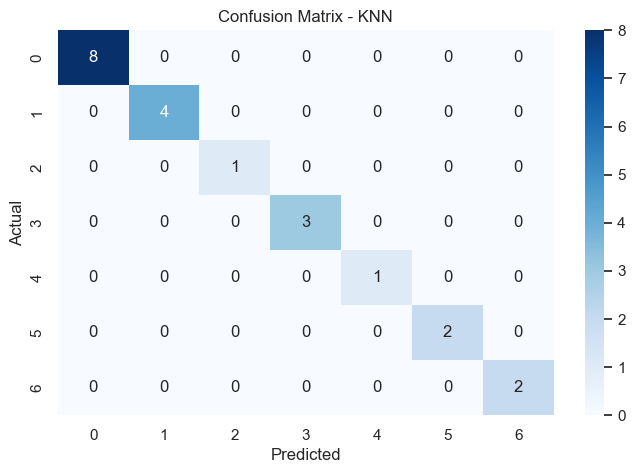

In [22]:
# Confusion matrix
plt.figure(figsize=(8, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 13. Compare Different Distance Metrics

Common distance metrics in KNN:
- Euclidean distance
- Manhattan distance
- Minkowski distance


In [23]:
metrics = {
    "Euclidean": {"metric": "minkowski", "p": 2},
    "Manhattan": {"metric": "minkowski", "p": 1}
}

for metric_name, params in metrics.items():
    model = KNeighborsClassifier(
        n_neighbors=best_k,
        metric=params["metric"],
        p=params["p"]
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    print(metric_name, "Accuracy:", accuracy_score(y_test, pred))

Euclidean Accuracy: 1.0
Manhattan Accuracy: 1.0


## 14. Decision Boundary Visualization

The dataset has many features, so direct decision boundary plotting is not possible in full dimensions.  
Therefore, we use **PCA** to reduce the dataset to 2 dimensions and then plot the decision boundary.


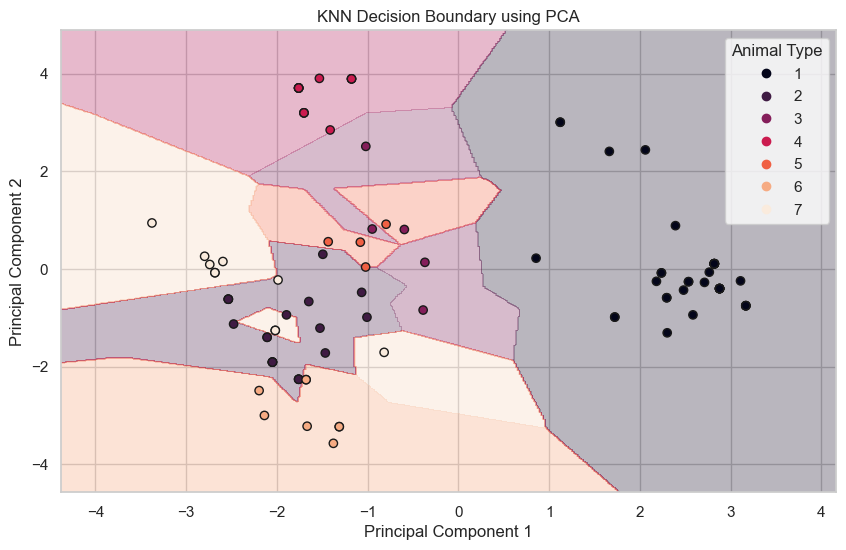

In [24]:
# Reduce features to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Train KNN on PCA features
knn_pca = KNeighborsClassifier(n_neighbors=best_k)
knn_pca.fit(X_train_pca, y_train_pca)

# Create mesh grid
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolor="k")
plt.title("KNN Decision Boundary using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(*scatter.legend_elements(), title="Animal Type")
plt.show()

## 15. Cluster/Classification Insights

From the analysis:
- Animal types are distributed across 7 classes.
- Features like `hair`, `feathers`, `milk`, `eggs`, `aquatic`, `backbone`, and `legs` are useful for classification.
- KNN works well for this dataset because most features are binary and animal classes have clear patterns.
- Scaling is important because KNN uses distance calculations.
- PCA visualization gives an approximate 2D view of the decision regions.


# Interview Questions

## 1. What are the key hyperparameters in KNN?

Important hyperparameters of KNN are:

1. **n_neighbors (K):**  
   Number of nearest neighbors considered for classification.  
   Small K can make the model sensitive to noise, while large K can make it too smooth.

2. **Distance metric:**  
   Defines how distance is calculated between data points. Examples include Euclidean, Manhattan, and Minkowski.

3. **weights:**  
   Determines whether all neighbors have equal importance or closer neighbors get more weight.  
   Common values are `uniform` and `distance`.

4. **p value:**  
   Used with Minkowski distance.  
   `p=1` means Manhattan distance and `p=2` means Euclidean distance.

5. **algorithm:**  
   Method used to find nearest neighbors, such as `auto`, `ball_tree`, `kd_tree`, or `brute`.

## 2. What distance metrics can be used in KNN?

Common distance metrics used in KNN are:

1. **Euclidean Distance:**  
   Straight-line distance between two points.

2. **Manhattan Distance:**  
   Sum of absolute differences between coordinates.

3. **Minkowski Distance:**  
   Generalized distance metric. Euclidean and Manhattan are special cases of Minkowski distance.

4. **Hamming Distance:**  
   Used mostly for categorical or binary data.

5. **Cosine Distance:**  
   Measures the angle-based similarity between vectors, often used in text or high-dimensional data.


# Final Conclusion

In this assignment, the K-Nearest Neighbours algorithm was implemented on the Zoo dataset to classify animal types.  
The dataset was cleaned, analyzed, visualized, scaled, and split into training and testing sets.  
Different values of K were tested, and the best K value was selected based on testing accuracy.  
The final model was evaluated using accuracy, precision, recall, and F1-score.  
Decision boundaries were visualized using PCA because the original dataset has multiple dimensions.

KNN is simple and effective for this dataset because the animal classes have clear feature patterns.
